<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

netid = "lsantucc"
df = pd.read_csv(f"{netid}_project_summary.csv", sep=";")
df.columns = ['project', 'commit', 'author', 'time', 'message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.to_period('M')

projects = df['project'].unique()
print(projects)   # copy exact names from here

['covid19datahub_covid19dev' 'echonet_dynamic'
 'opengeospatial_ogc-geosparql' 'egri-nagy_sgpdec' 'eendebakpt_oapackage'
 'wojdyr_fityk' 'smearle_gym-city' 'acclab_dabestr' 'aol_moloch'
 'ncoudray_deeppath']


In [18]:
def monthly_series(df, prj):
    d = df[df['project'] == prj]
    counts = d.groupby('Month').size()
    full = pd.period_range(counts.index.min(), counts.index.max(), freq='M')
    counts = counts.reindex(full, fill_value=0)   # zero-commit months get 0
    return pd.DataFrame({'Month': full.strftime('%Y-%m'), '#Commits': counts.values})

In [19]:
def gap_stats(ts, min_gap=3):
    runs, start = [], None
    for i, c in enumerate(ts['#Commits']):
        if c == 0 and start is None:
            start = i
        elif c != 0 and start is not None:
            runs.append((start, i - 1)); start = None
    if start is not None:
        runs.append((start, len(ts) - 1))

    if not runs:
        return dict(LongestGapStart=None, LongestGapEnd=None, LongestGapLength=0,
                    NumCommitsAfterLastGap=None, NumberOfGapsInTimeline=0)

    s, e = max(runs, key=lambda r: r[1] - r[0])   # first longest gap if tied
    return dict(
        LongestGapStart=ts['Month'][s],
        LongestGapEnd=ts['Month'][e],
        LongestGapLength=e - s + 1,
        NumCommitsAfterLastGap=int(ts['#Commits'][e + 1:].sum()),
        NumberOfGapsInTimeline=sum(1 for a, b in runs if b - a + 1 >= min_gap),
    )

In [20]:
github = {
    'covid19datahub_covid19dev':    {'stars': 252,  'forks': 92,   'last_commit': '2025-06-30'},
    'echonet_dynamic':              {'stars': 164,  'forks': 48,   'last_commit': '2026-05-01'},
    'opengeospatial_ogc-geosparql': {'stars': 105,  'forks': 21,   'last_commit': '2026-09-21'},
    'egri-nagy_sgpdec':             {'stars': 22,   'forks': 3,    'last_commit': '2026-06-30'},
    'eendebakpt_oapackage':         {'stars': 39,   'forks': 10,   'last_commit': '2026-02-04'},
    'wojdyr_fityk':                 {'stars': 306,  'forks': 61,   'last_commit': '2026-03-02'},
    'smearle_gym-city':             {'stars': 161,  'forks': 24,   'last_commit': '2025-04-04'},
    'acclab_dabestr':               {'stars': 230,  'forks': 38,   'last_commit': '2026-07-29'},
    'aol_moloch':                   {'stars': 7509, 'forks': 1168, 'last_commit': '2026-09-28'},
    'ncoudray_deeppath':            {'stars': 537,  'forks': 214,  'last_commit': '2024-09-24'},
}

patterns = {
    'covid19datahub_covid19dev':    'declining',
    'echonet_dynamic':              'irregular',
    'opengeospatial_ogc-geosparql': 'cyclical',
    'egri-nagy_sgpdec':             'irregular',
    'eendebakpt_oapackage':         'cyclical',
    'wojdyr_fityk':                 'cyclical',
    'smearle_gym-city':             'declining',
    'acclab_dabestr':               'U-shaped',
    'aol_moloch':                   'rising',
    'ncoudray_deeppath':            'U-shaped',
}
# options: steady, rising, declining, U-shaped, cyclical, irregular

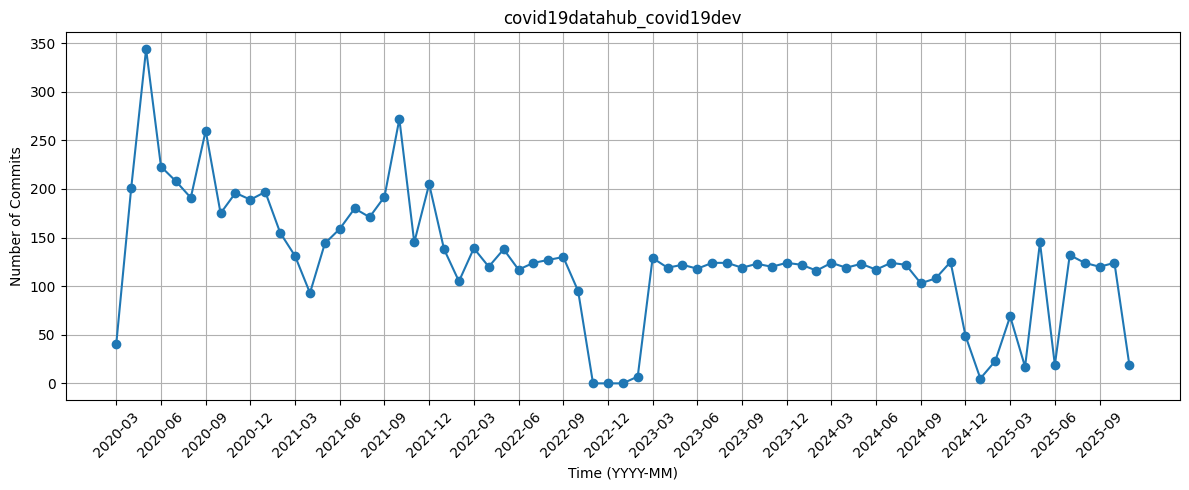

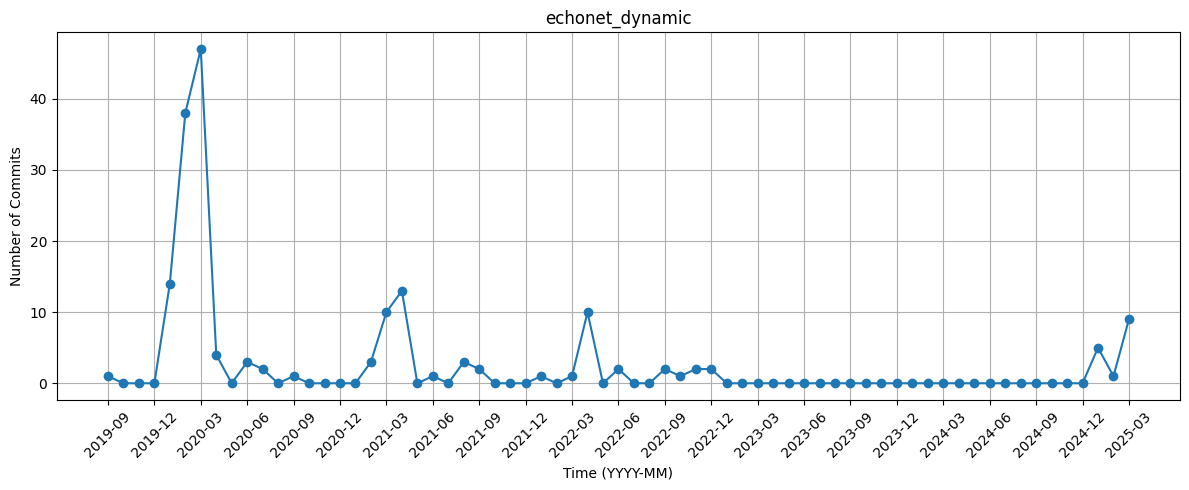

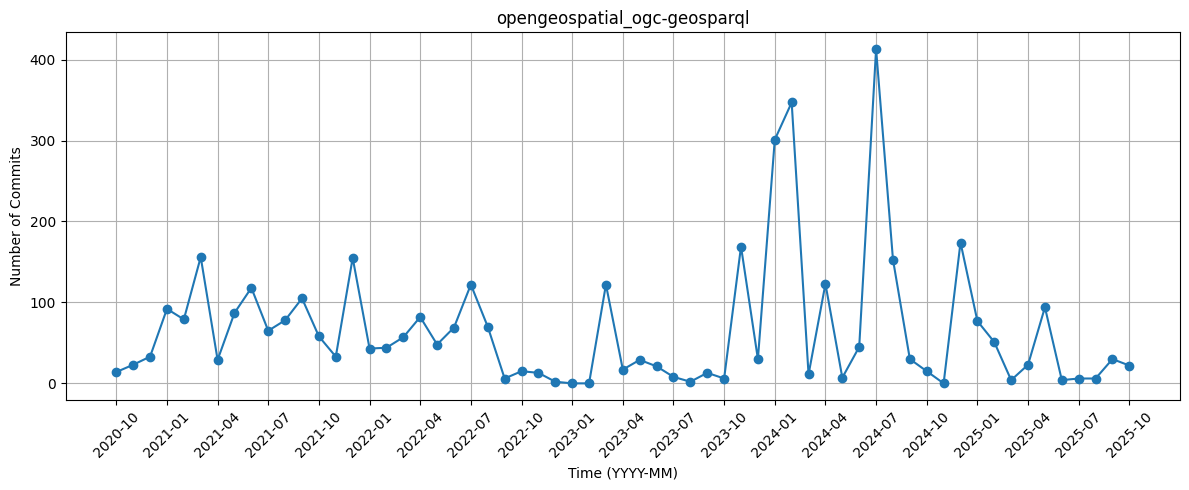

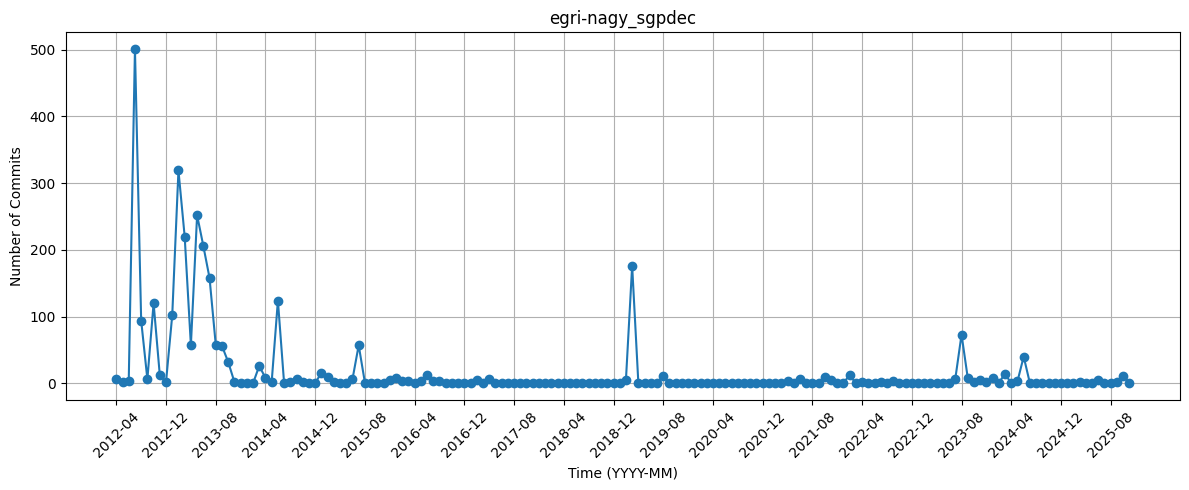

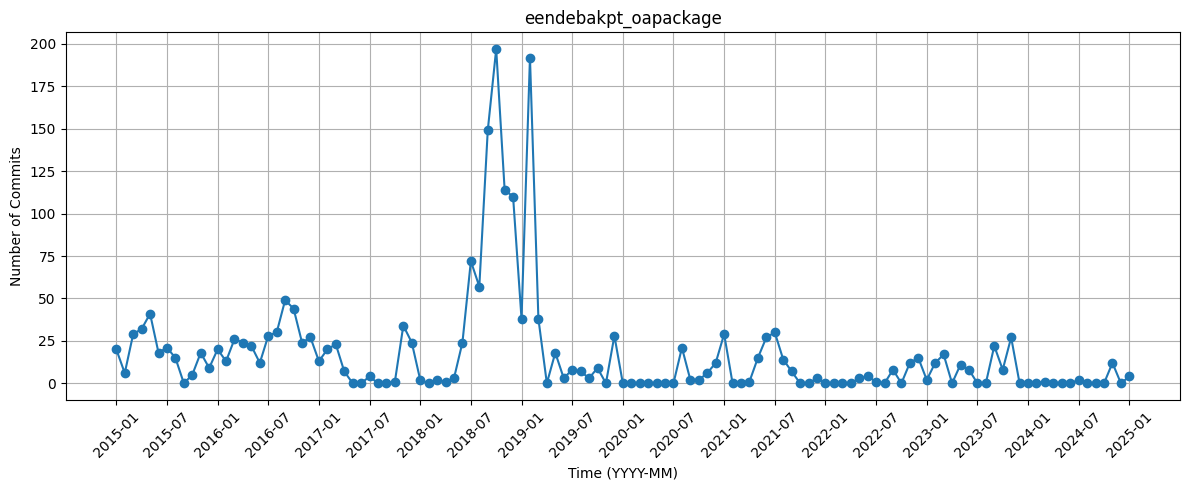

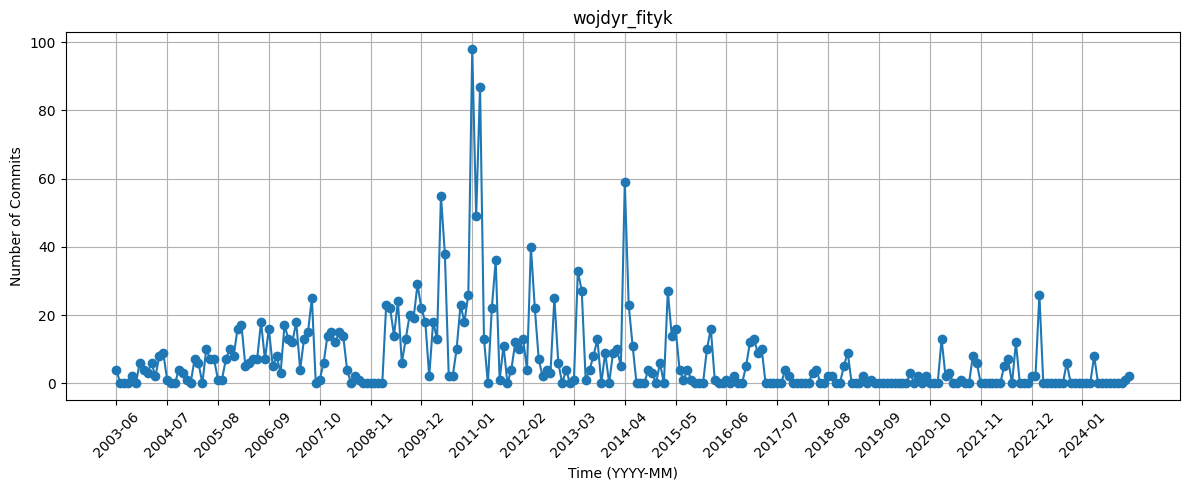

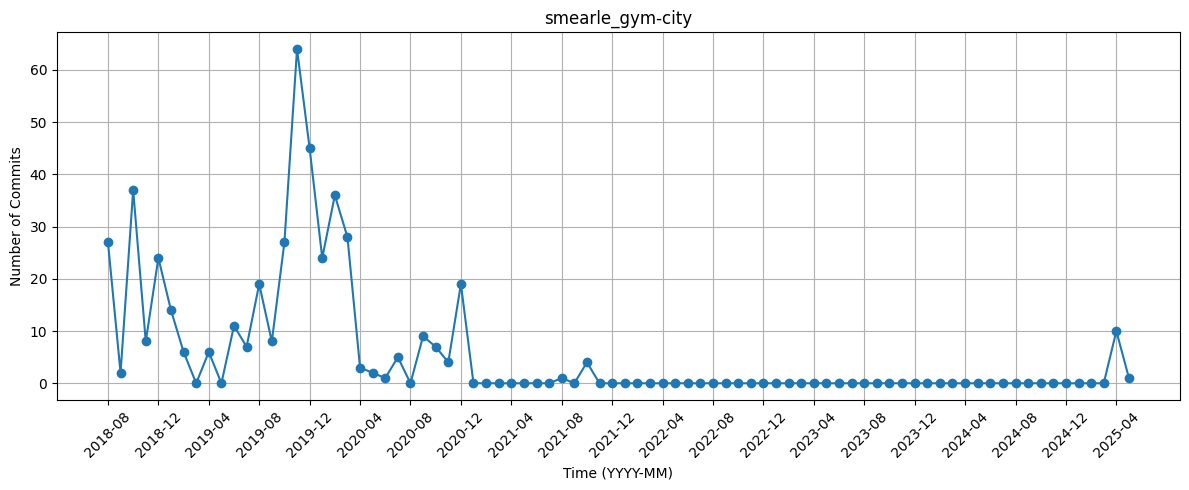

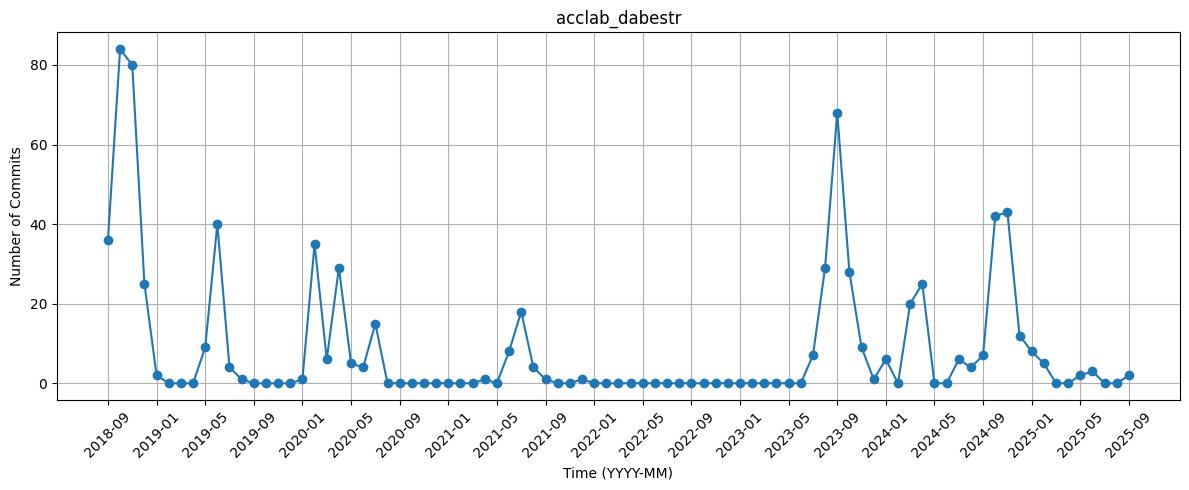

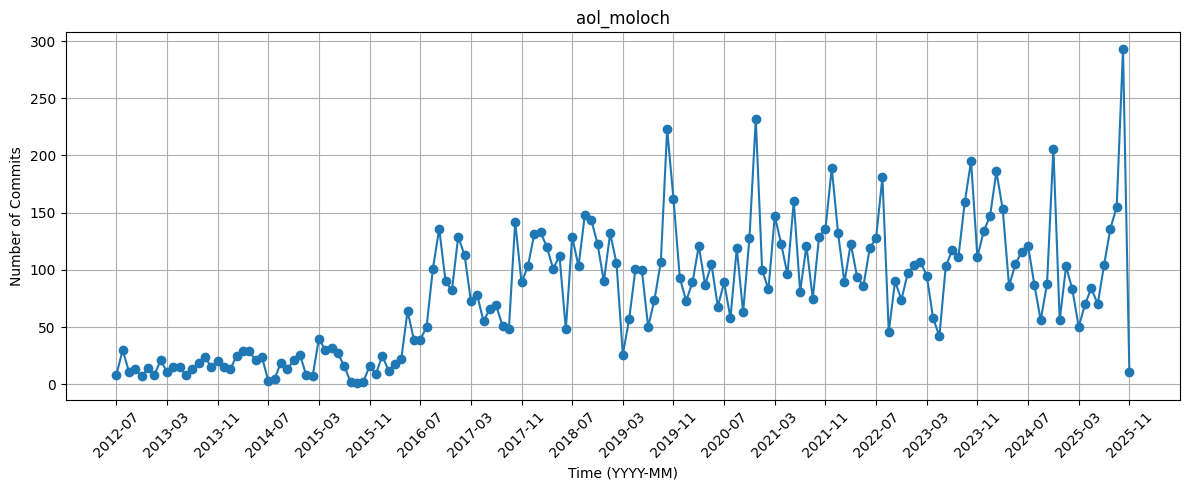

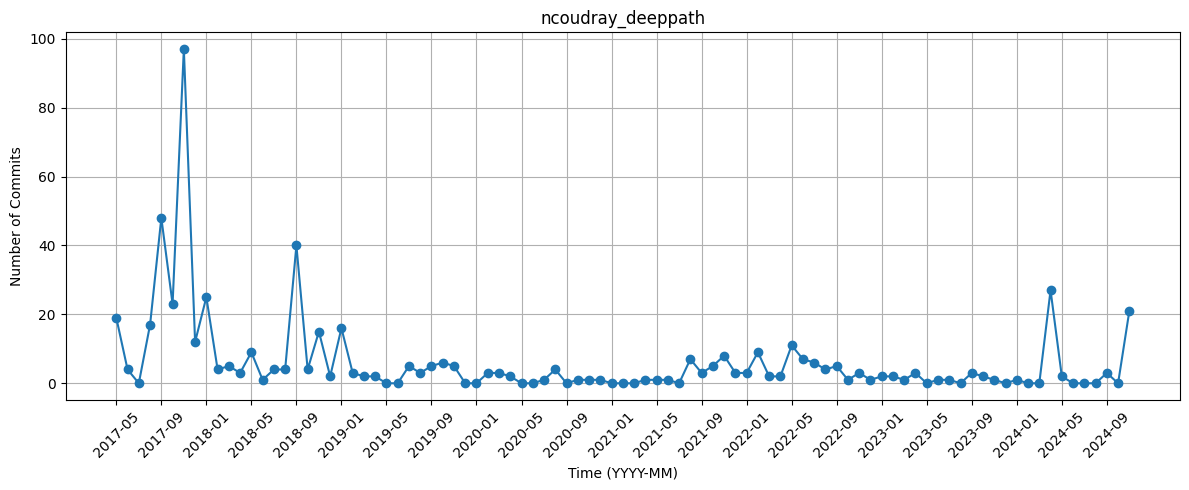

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,covid19datahub_covid19dev,8683,35,2020-03-24,2025-11-05,252,92,2025-06-30,2022-11,2023-01,3,3378,1,declining
1,echonet_dynamic,178,9,2019-09-25,2025-03-15,164,48,2026-05-01,2023-01,2024-12,24,15,4,irregular
2,opengeospatial_ogc-geosparql,4049,44,2020-10-09,2025-10-23,105,21,2026-09-21,2023-01,2023-02,2,2353,0,cyclical
3,egri-nagy_sgpdec,2955,19,2012-04-19,2025-11-04,22,3,2026-06-30,2018-01,2019-01,13,427,11,irregular
4,eendebakpt_oapackage,2072,17,2015-01-29,2025-01-26,39,10,2026-02-04,2020-01,2020-07,7,338,5,cyclical
5,wojdyr_fityk,1840,21,2003-06-17,2025-01-30,306,61,2026-03-02,2019-08,2020-04,9,111,14,cyclical
6,smearle_gym-city,459,12,2018-08-21,2025-05-06,161,24,2025-04-04,2021-11,2025-03,41,11,2,declining
7,acclab_dabestr,736,28,2018-09-21,2025-09-15,230,38,2026-07-29,2022-01,2023-06,18,327,4,U-shaped
8,aol_moloch,12825,292,2012-07-06,2025-11-03,7509,1168,2026-09-28,None,None,0,<NA>,0,rising
9,ncoudray_deeppath,552,24,2017-05-23,2024-11-25,537,214,2024-09-24,2021-01,2021-03,3,153,2,U-shaped


In [21]:
rows = []
for prj in projects:
    ts = monthly_series(df, prj)
    ts.to_csv(f"{netid}_commits_timeseries_{prj}.csv", sep=";", index=False)

    plt.figure(figsize=(12, 5))
    plt.plot(ts['Month'], ts['#Commits'], marker='o', linestyle='-')
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(prj)
    plt.grid(True)
    step = max(1, len(ts) // 20)   # keep x labels readable on long timelines
    plt.xticks(range(0, len(ts), step), ts['Month'][::step], rotation=45)
    plt.tight_layout()
    plt.savefig(f"{netid}_timeseries_{prj}.png", dpi=300)
    plt.show()

    d = df[df['project'] == prj]
    gh = github.get(prj, {})
    rows.append({
        'Project': prj,
        'ncommits': len(d),
        'nauthors': d['author'].nunique(),
        'from': pd.to_datetime(d['time'].min(), unit='s').strftime('%Y-%m-%d'),
        'to': pd.to_datetime(d['time'].max(), unit='s').strftime('%Y-%m-%d'),
        'nstars': gh.get('stars'),
        'nforks': gh.get('forks'),
        'lastGHCommitDate': gh.get('last_commit'),
        **gap_stats(ts),
        'ActivityPattern': patterns.get(prj),
    })

stats = pd.DataFrame(rows)
stats['NumCommitsAfterLastGap'] = stats['NumCommitsAfterLastGap'].astype('Int64')   # 3378.0 -> 3378
stats[['LongestGapStart', 'LongestGapEnd']] = stats[['LongestGapStart', 'LongestGapEnd']].fillna('None')
stats.to_csv(f"{netid}_project_stats.csv", sep=";", index=False)
stats

## Interpretation

Each project's monthly commit time series was classified by its overall trajectory:
**steady, rising, declining, or U-shaped** (long-term movement in activity levels),
**cyclical** (bursts of activity repeating at fairly regular intervals), or
**irregular** (unpredictable variation with no clear trend or rhythm). A gap is
defined as 3 or more consecutive months with zero commits.

**covid19datahub_covid19dev**: *Declining.* Activity was highest early in the
timeline, when COVID-19 data collection was most urgent, and dropped off as the
pandemic wound down and the data became less in demand. Later commits are sparse
maintenance updates. Gaps of 3+ months: 1.

**echonet_dynamic**: *Irregular.* Commits show up in scattered bursts with no
consistent long-term direction or repeating interval, which fits a research
codebase that gets updated when needed rather than on a schedule.
Gaps of 3+ months: 4.

**opengeospatial_ogc-geosparql**: *Cyclical.* Activity comes in recurring bursts
separated by quiet periods, which fits a standards project whose work is tied to
periodic review and release cycles. Gaps of 3+ months: 0.

**egri-nagy_sgpdec**: *Irregular.* Commit activity is sporadic, with isolated
spikes and long quiet stretches and no clear trend or rhythm, which is typical of
a small project maintained by one or a few people. Gaps of 3+ months: 11.

**eendebakpt_oapackage**: *Cyclical.* Bursts of commits recur at fairly regular
intervals, likely matching release or maintenance cycles, with lower activity in
between. Gaps of 3+ months: 5.

**wojdyr_fityk**: *Cyclical.* The project shows repeated waves of activity over
a long lifespan, consistent with periodic development pushes and releases followed
by quieter maintenance periods. Gaps of 3+ months: 14.

**smearle_gym-city**: *Declining.* Most activity happened early, during active
research development, and commits tapered off afterward, a common trajectory for
academic research repositories after the associated work is completed.
Gaps of 3+ months: 2.

**acclab_dabestr**: *U-shaped.* Activity was high early on, dropped into a long
low period in the middle, then picked back up later, suggesting the project was
revived, possibly for a major rewrite or new release. Gaps of 3+ months: 4.

**aol_moloch**: *Rising.* Commit activity increased over time as the project
grew in adoption and contributors. The project had no months without commits, so
it has no longest gap. Gaps of 3+ months: 0.

**ncoudray_deeppath**: *U-shaped.* Early activity during initial development was
followed by a long period of inactivity, then a return of commits later in the
timeline, suggesting renewed interest or maintenance after the original research
phase. Gaps of 3+ months: 2.

### Overall
Research-oriented repositories (covid19datahub, gym-city, deeppath, echonet) tend
to be declining, irregular, or U-shaped, peaking around active research and then
going quiet. Longer-lived tools and standards (fityk, oapackage, geosparql) show
cyclical, release-driven activity. aol_moloch, the largest and most widely used
project, was the only one with continuous, rising activity and no inactive months.